In [8]:
# ============================================================
# Proper Train/Test Evaluation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

df = pd.read_csv("/kaggle/input/notebooks/ben314159/irrationality-simulation/lhs_alpha_results.csv")
df = df.dropna()

target = "alpha_weighted"
param_cols = [
    "pi_true",
    "fitness_L",
    "sigma",
    "T",
    "fitness_F",
    "prior_strength",
]

X = df[param_cols].values
y = df[target].values

count    5000.000000
mean        0.869576
std         0.588991
min         0.199526
25%         0.683397
50%         0.765455
75%         0.857365
max         5.011872
Name: alpha_weighted, dtype: float64


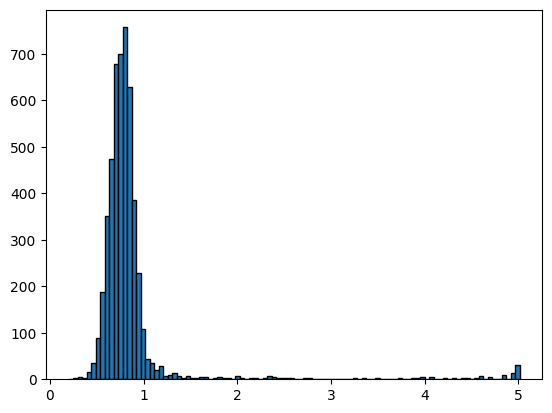

In [9]:
print(df["alpha_weighted"].describe())
plt.hist(df["alpha_weighted"], bins=100, edgecolor="k")
plt.show()

In [3]:
# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Linear Model (with scaling)
# ------------------------------------------------------------

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin = LinearRegression()
lin.fit(X_train_scaled, y_train)

y_pred_train_lin = lin.predict(X_train_scaled)
y_pred_test_lin = lin.predict(X_test_scaled)

r2_train_lin = r2_score(y_train, y_pred_train_lin)
r2_test_lin = r2_score(y_test, y_pred_test_lin)

print("\n=== Linear Regression ===")
print("Train R²:", r2_train_lin)
print("Test  R²:", r2_test_lin)

# Cross-validated R²
cv_lin = cross_val_score(
    lin,
    scaler.fit_transform(X),
    y,
    cv=5,
    scoring="r2"
)

print("CV R² mean:", np.mean(cv_lin))
print("CV R² std :", np.std(cv_lin))

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("\n=== Random Forest ===")
print("Train R²:", r2_train_rf)
print("Test  R²:", r2_test_rf)

# Cross-validated RF
cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV R² mean:", np.mean(cv_rf))
print("CV R² std :", np.std(cv_rf))

# ------------------------------------------------------------
# True Out-of-Sample Signal-to-Noise
# ------------------------------------------------------------

signal_var = np.var(y_pred_test_lin)
noise_var = np.var(y_test - y_pred_test_lin)

snr_test = signal_var / noise_var

print("\nOut-of-Sample Linear SNR:", snr_test)


=== Linear Regression ===
Train R²: 0.14363744652609955
Test  R²: 0.14706015035291753
CV R² mean: 0.13443078954969073
CV R² std : 0.0317952356920794

=== Random Forest ===
Train R²: 0.9659612007230052
Test  R²: 0.747479880018254
CV R² mean: 0.7640506497120731
CV R² std : 0.05310388893159514

Out-of-Sample Linear SNR: 0.14954483465481616


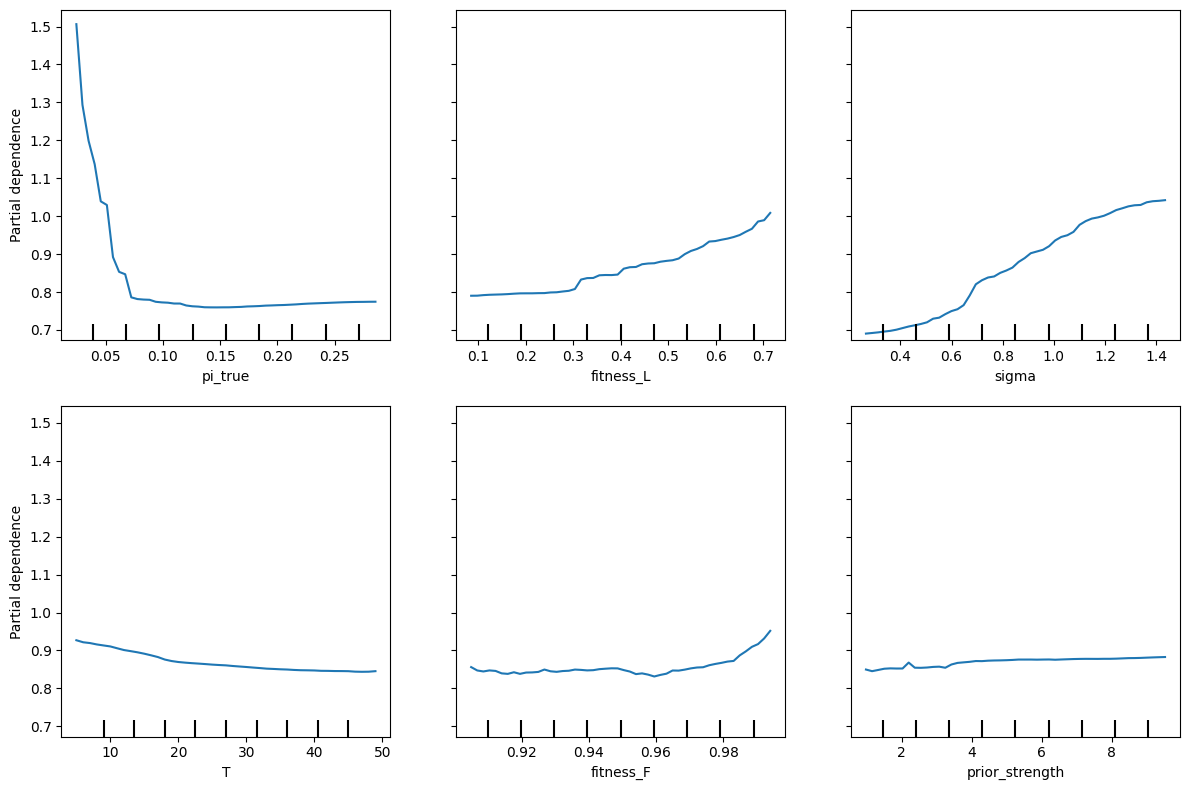

In [4]:
# ============================================================
# Partial Dependence Plots
# ============================================================

import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)

features = list(range(len(param_cols)))

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features=features,
    feature_names=param_cols,
    grid_resolution=50,
    ax=ax,
)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



=== Permutation Importances ===
pi_true           1.080813
sigma             0.548794
fitness_L         0.398420
fitness_F         0.305184
prior_strength    0.030783
T                 0.003438
dtype: float64


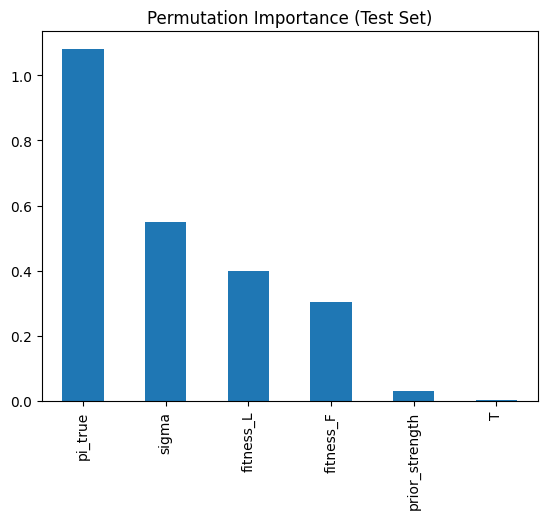

In [5]:
from sklearn.inspection import permutation_importance

rf.fit(X_train, y_train)

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm.importances_mean,
    index=param_cols
).sort_values(ascending=False)

print("\n=== Permutation Importances ===")
print(importances)

importances.plot(kind="bar")
plt.title("Permutation Importance (Test Set)")
plt.show()

In [10]:
df["loss_ratio"] = (df["pi_true"] * np.log(df["fitness_L"])) / ((1.0 - df["pi_true"]) * np.log(df["fitness_F"]))
df["precision"] = 1 / df["sigma"]
df["horizon"] = df["T"] / df["prior_strength"]
df["ultimate"] = df["loss_ratio"]+df["precision"]

In [12]:
target = "alpha_weighted"
param_cols = [
    "loss_ratio",
    "precision",
    "horizon"
]

X = df[param_cols].values
y = df[target].values

# ------------------------------------------------------------
# Train / Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ------------------------------------------------------------
# Random Forest
# ------------------------------------------------------------

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train_rf = rf.predict(X_train)
y_pred_test_rf = rf.predict(X_test)

r2_train_rf = r2_score(y_train, y_pred_train_rf)
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("\n=== Random Forest ===")
print("Train R²:", r2_train_rf)
print("Test  R²:", r2_test_rf)

# Cross-validated RF
cv_rf = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("CV R² mean:", np.mean(cv_rf))
print("CV R² std :", np.std(cv_rf))


=== Random Forest ===
Train R²: 0.9767869870776097
Test  R²: 0.8184662490236155
CV R² mean: 0.8098502236630676
CV R² std : 0.0535824777752199


In [ ]:
features = list(range(len(param_cols)))

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features=features,
    feature_names=param_cols,
    grid_resolution=50,
    ax=ax
)
plt.tight_layout()
plt.show()

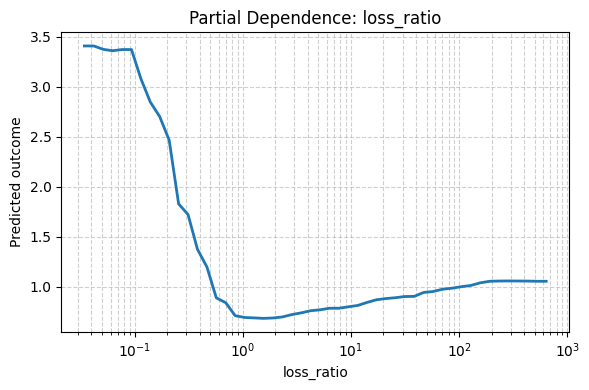

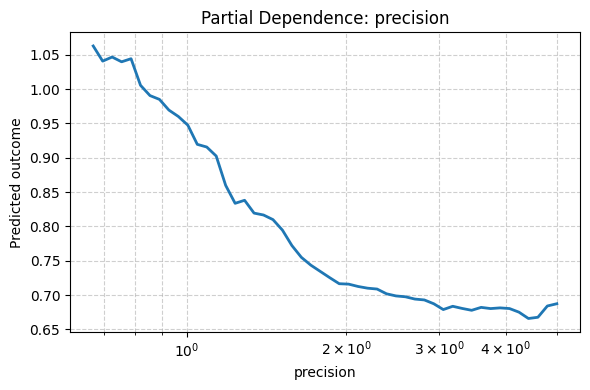

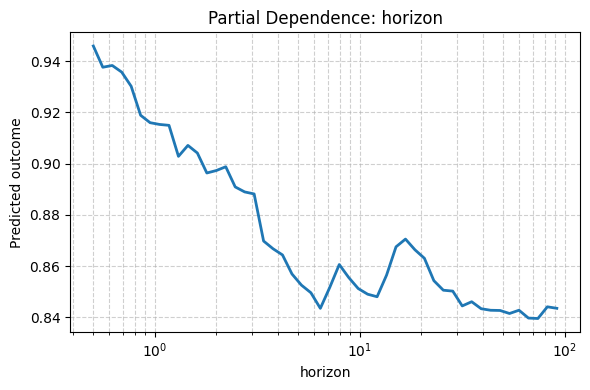

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def log_partial_dependence(model, X, feature_index, grid_points=50):
    """
    Compute PDP on a log-spaced grid for one feature.
    """

    X_temp = X.copy()
    feature_values = X[:, feature_index]

    # Create log-spaced grid using data range
    min_val = feature_values.min()
    max_val = feature_values.max()

    grid = np.logspace(
        np.log10(min_val),
        np.log10(max_val),
        grid_points
    )

    pdp = []

    for val in grid:
        X_temp[:, feature_index] = val
        preds = model.predict(X_temp)
        pdp.append(np.mean(preds))

    return grid, np.array(pdp)

features = list(range(len(param_cols)))

for i in features:

    fig, ax = plt.subplots(figsize=(6, 4))

    grid, pdp_vals = log_partial_dependence(rf, X, i)

    ax.plot(grid, pdp_vals, linewidth=2)

    ax.set_xscale("log")
    ax.set_title(f"Partial Dependence: {param_cols[i]}")
    ax.set_xlabel(param_cols[i])
    ax.set_ylabel("Predicted outcome")

    ax.grid(True, which="both", linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


=== Permutation Importances ===
loss_ratio    1.516840
precision     0.696497
horizon       0.048422
dtype: float64


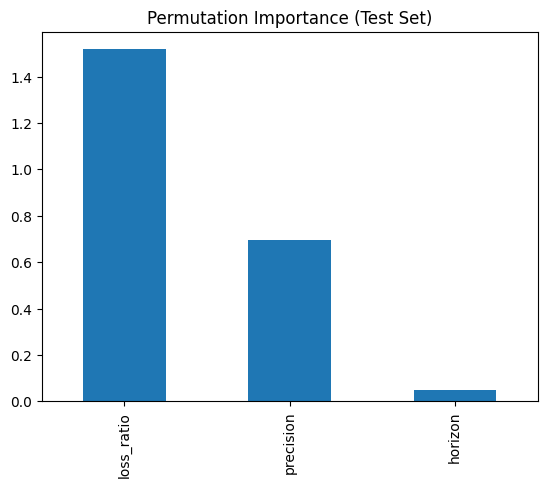

In [14]:
from sklearn.inspection import permutation_importance

rf.fit(X_train, y_train)

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

importances = pd.Series(
    perm.importances_mean,
    index=param_cols
).sort_values(ascending=False)

print("\n=== Permutation Importances ===")
print(importances)

importances.plot(kind="bar")
plt.title("Permutation Importance (Test Set)")
plt.show()

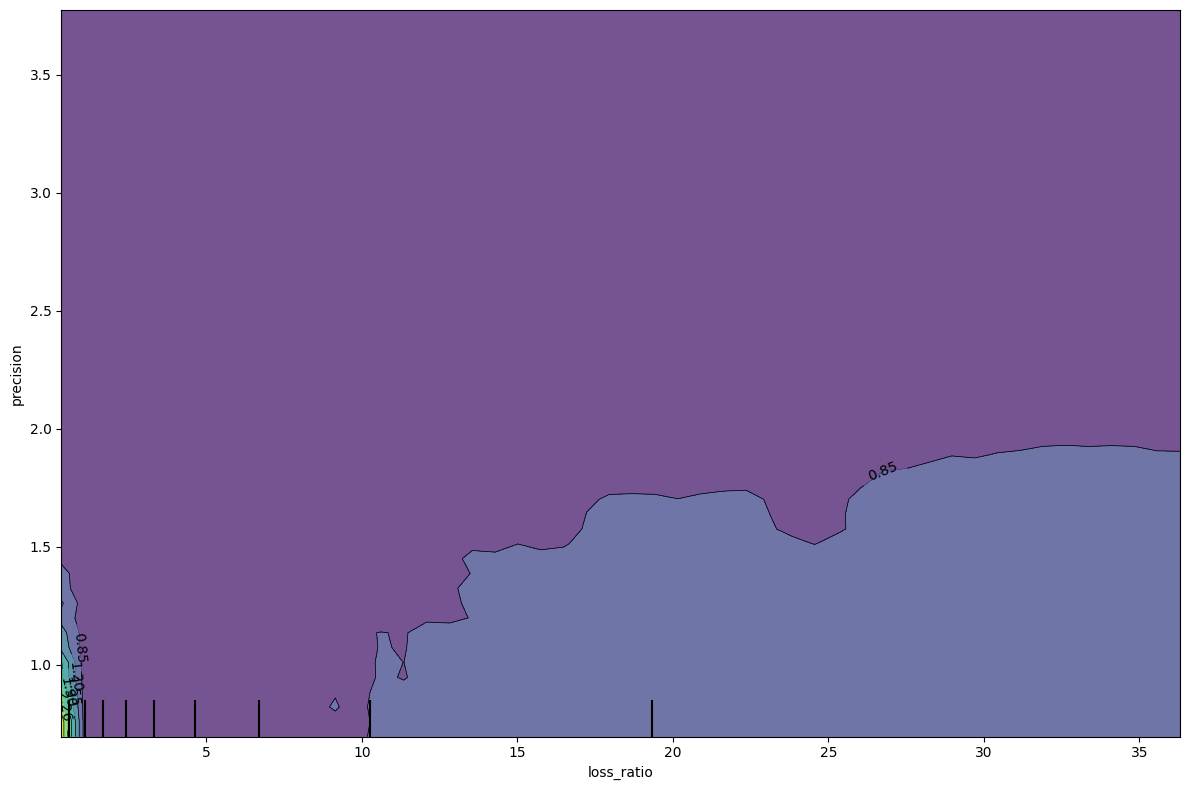

In [17]:
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    rf,
    X,
    features=[(0,1)],
    feature_names=param_cols,
    grid_resolution=50,
    ax=ax
)
plt.tight_layout()
plt.show()